In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("train.csv")

# Quick overview
print(df.head())
print(df.info())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

In [2]:
# Missing values check
missing_values = df.isnull().sum().sort_values(ascending=False)
print(missing_values)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64


In [3]:
survival_rate = df["Survived"].value_counts(normalize=True) * 100
print(survival_rate)

0    61.616162
1    38.383838
Name: Survived, dtype: float64


In [5]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [6]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [7]:
df.drop(columns=["Cabin"], inplace=True)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df["Sex"] = df["Sex"].str.lower()

In [10]:
# Target variable
y = df["Survived"]

# Drop unnecessary columns
X = df.drop(columns=["Survived", "PassengerId", "Name", "Ticket"])

In [11]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)
print(X.head())

Features shape: (891, 7)
Target shape: (891,)
   Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0       3    male  22.0      1      0   7.2500        S
1       1  female  38.0      1      0  71.2833        C
2       3  female  26.0      0      0   7.9250        S
3       1  female  35.0      1      0  53.1000        S
4       3    male  35.0      0      0   8.0500        S


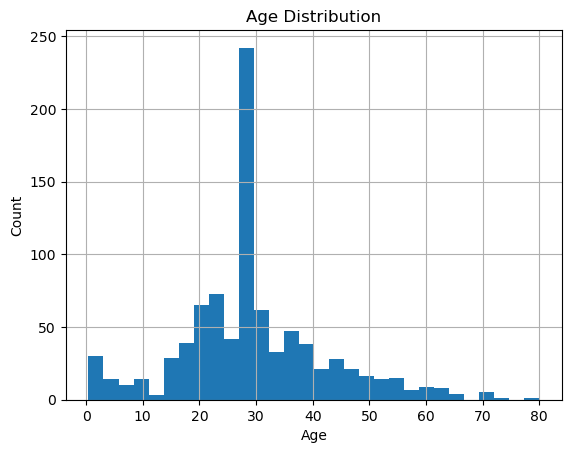

In [12]:
import matplotlib.pyplot as plt

df["Age"].hist(bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

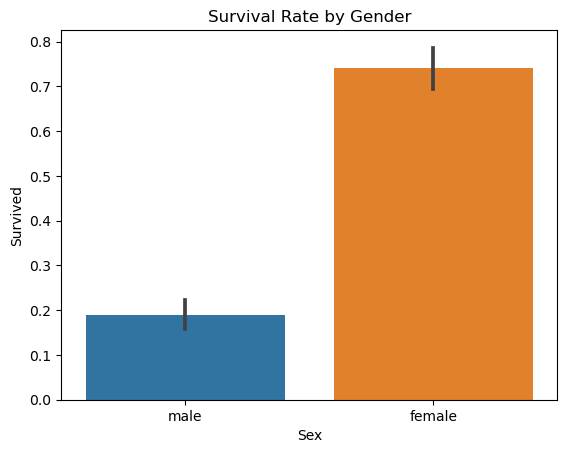

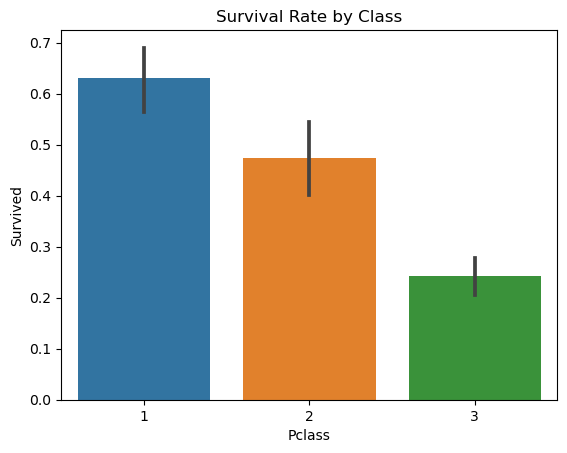

In [13]:
import seaborn as sns

sns.barplot(x="Sex", y="Survived", data=df)
plt.title("Survival Rate by Gender")
plt.show()

sns.barplot(x="Pclass", y="Survived", data=df)
plt.title("Survival Rate by Class")
plt.show()

In [14]:
import pandas as pd

df = pd.read_csv("train.csv")

# Missing values
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin
df.drop(columns=["Cabin"], inplace=True)

# Clean duplicates
df.drop_duplicates(inplace=True)

# Standardize text
df["Sex"] = df["Sex"].str.lower()

# Features & target
y = df["Survived"]
X = df.drop(columns=["Survived", "PassengerId", "Name", "Ticket"])

print("Final shape:", X.shape, y.shape)

Final shape: (891, 7) (891,)


# Titanic Dataset Cleaning — Final Summary

## Problem Overview
The Titanic dataset is a binary classification problem. The goal is to predict whether a passenger survived (1) or did not survive (0). The dataset includes features such as age, sex, passenger class, fare, and embarkation port.

## Data Cleaning Steps

### Missing Value Handling
- Missing values in the Age column were filled using the median value.
- Missing values in the Embarked column were filled using the most frequent value (mode).

### Feature Removal
- The Cabin column was removed due to a large number of missing values.
- PassengerId, Name, and Ticket were removed because they are identifier columns and do not help in prediction.

### Data Consistency
- The Sex column was converted to lowercase for consistency.
- Duplicate records were checked and removed.

## Key Observations

### Survival Rate
- Around 38% of passengers survived.
- Around 62% did not survive.

### Age Distribution
- Most passengers were young adults.
- Missing age values were handled without significantly changing the overall distribution.

### Survival Patterns
- Females had a higher survival rate than males.
- Passengers in first class had higher survival chances.
- Passenger class had a strong impact on survival.

## Feature Engineering Notes
- The Cabin column was dropped but could be improved by extracting deck information.
- Categorical features like Sex and Embarked will need encoding before model training.

## Key Insights

### Why median was used for Age
Median is used because it is not affected by extreme values (outliers) and gives a more stable result.

### Why mode was used for Embarked
Mode is used because it represents the most common category, but it may introduce slight bias.

## Final Conclusion
Data preprocessing is an important step in machine learning. Proper handling of missing values, irrelevant features, and inconsistencies improves data quality and leads to better model performance.